A discrete random variable assigns positive probability to countably many values.

A **continuous random variable** distributes its probability over intervals rather than individual points. In this lecture we study the most important class of continuous distributions: **absolutely continuous distributions**.

# Probability Distributions

A **probability distribution** on $\mathbb R$ is a probability measure

$$
P:\mathcal B(\mathbb R)\rightarrow[0,1],
$$

where $\mathcal B(\mathbb R)$ denotes the Borel $\sigma$-algebra.

## Cumulative Distribution Function

The cumulative distribution function (CDF) of a random variable $\xi$ is defined by

$$
F_{\xi}(x)=P(\xi\le x),\qquad x\in\mathbb R.
$$

Notice that the CDF completely determines the probability distribution.

In other words, if two random variables have the same cumulative distribution function, then they have the same distribution.

### Properties of the CDF
1. $F(x)$ is non-decreasing.
2. $\displaystyle\lim_{x\to-\infty}F(x)=0$ and $\displaystyle\lim_{x\to\infty}F(x)=1$.
3. $F(x)$ is right-continuous.

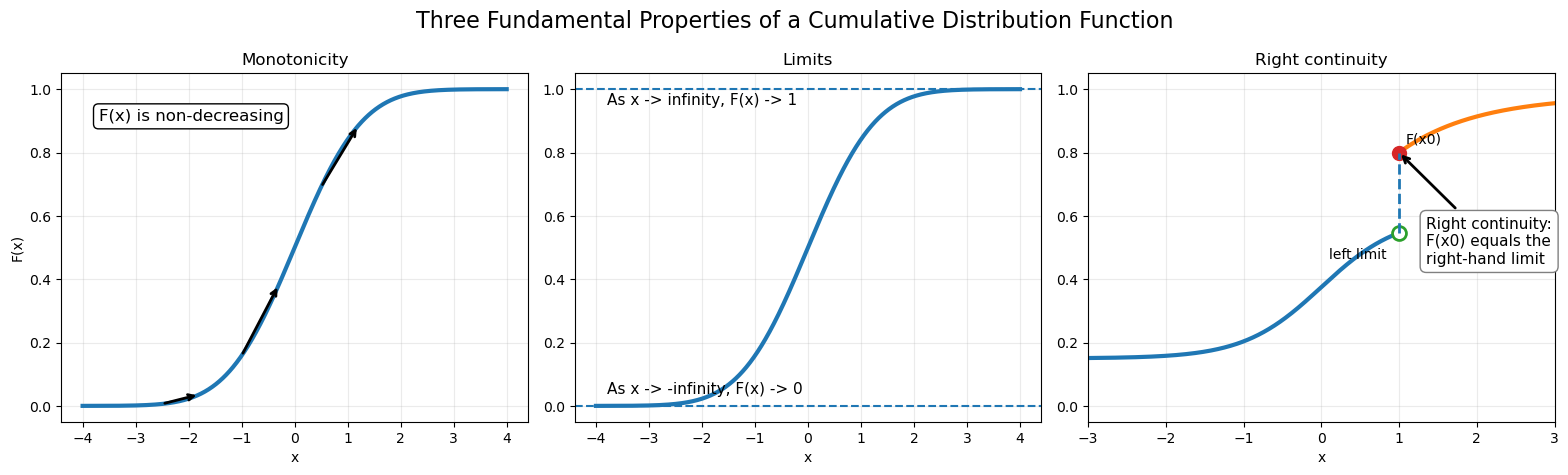

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

x = np.linspace(-4, 4, 1000)
F = norm.cdf(x)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))

# =====================================================
# (1) Monotonicity
# =====================================================

ax = axes[0]

ax.plot(x, F, linewidth=3)
ax.set_title("Monotonicity")

for x0 in [-2.5, -1, 0.5]:
    ax.annotate(
        "",
        xy=(x0 + 0.7, norm.cdf(x0 + 0.7)),
        xytext=(x0, norm.cdf(x0)),
        arrowprops=dict(arrowstyle="->", lw=2)
    )

ax.text(
    -3.7,
    0.9,
    "F(x) is non-decreasing",
    fontsize=12,
    bbox=dict(boxstyle="round", fc="white")
)

ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)

# =====================================================
# (2) Limits
# =====================================================

ax = axes[1]

ax.plot(x, F, linewidth=3)

ax.axhline(0, linestyle="--", linewidth=1.5)
ax.axhline(1, linestyle="--", linewidth=1.5)

ax.text(-3.8, 0.04, "As x -> -infinity, F(x) -> 0", fontsize=11)
ax.text(-3.8, 0.95, "As x -> infinity, F(x) -> 1", fontsize=11)

ax.set_ylim(-0.05, 1.05)
ax.set_title("Limits")
ax.set_xlabel("x")
ax.grid(alpha=0.25)

# =====================================================
# (3) Right continuity
# =====================================================

ax = axes[2]

x0 = 1.0

x_left = np.linspace(-3, x0, 400, endpoint=False)
x_right = np.linspace(x0, 3, 400)

F_left = 0.15 + 0.45 / (1 + np.exp(-2 * x_left))
F_right = 0.80 + 0.18 * (1 - np.exp(-(x_right - x0)))

left_limit = F_left[-1]
right_value = F_right[0]

ax.plot(x_left, F_left, linewidth=3)
ax.plot(x_right, F_right, linewidth=3)

# Open circle: left limit
ax.plot(
    x0,
    left_limit,
    marker="o",
    markersize=10,
    markerfacecolor="white",
    markeredgewidth=2
)

# Filled circle: actual value F(x0)
ax.plot(
    x0,
    right_value,
    marker="o",
    markersize=10
)

# Jump line
ax.vlines(
    x0,
    left_limit,
    right_value,
    linestyle="--",
    linewidth=2
)

ax.annotate(
    "Right continuity:\nF(x0) equals the\nright-hand limit",
    xy=(x0, right_value),
    xytext=(1.35, 0.45),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=2),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray")
)

ax.text(
    x0 - 0.9,
    left_limit - 0.08,
    "left limit",
    fontsize=10
)

ax.text(
    x0 + 0.08,
    right_value + 0.03,
    "F(x0)",
    fontsize=10
)

ax.set_ylim(-0.05, 1.05)
ax.set_xlim(-3, 3)
ax.set_title("Right continuity")
ax.set_xlabel("x")
ax.grid(alpha=0.25)

plt.suptitle(
    "Three Fundamental Properties of a Cumulative Distribution Function",
    fontsize=16
)

plt.tight_layout()
plt.show()

There are three fundamentally different types of probability distributions:

1. **Discrete distributions;**
2. **Singular distributions;**
3. **Absolutely continuous distributions.**

Moreover, every probability distribution can be uniquely decomposed into a mixture of these three types.

A **singular distribution** is concentrated on an uncountable set of Lebesgue measure zero, while assigning probability zero to every individual point.

The most famous example is the **Cantor distribution**, whose cumulative distribution function is known as the *Devil's staircase*.

In this course we will only study **discrete** and **absolutely continuous** distributions.

## Discrete Probability Distributions

A probability distribution is called **discrete** if there exists a finite or countable set

$$
X=\{x_1,x_2,\ldots\}\subset\mathbb R
$$

such that $P(X)=1$.

## Example 1: Bernoulli Distribution

Let $X\sim\operatorname{Bernoulli}(p)$. Its cumulative distribution function is

$$
F(x)=
\begin{cases}
0,&x<0,\\[1ex]
1-p,&0\le x<1,\\[1ex]
1,&x\ge1.
\end{cases}
$$

Notice that the CDF is a step function with jumps equal to the probabilities of the corresponding outcomes.

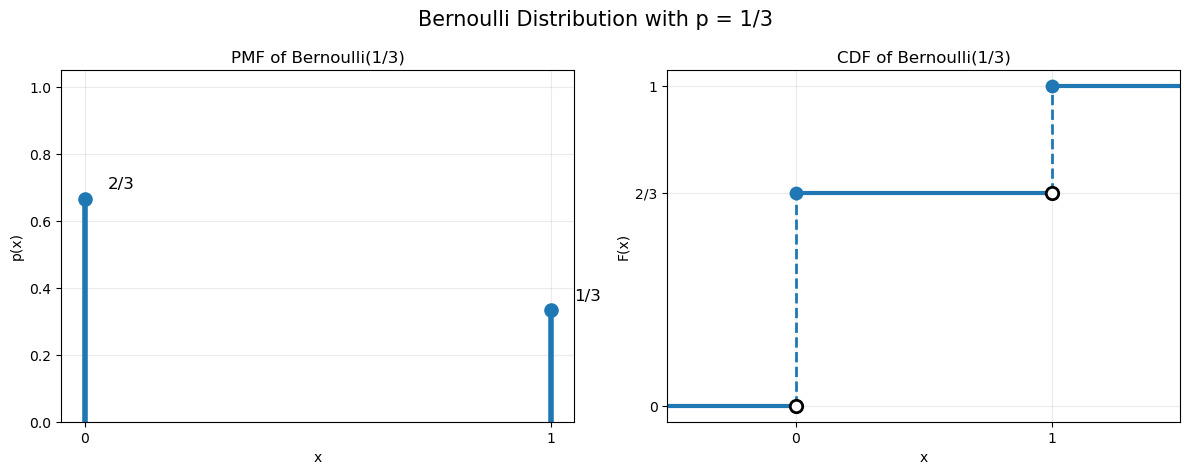

In [17]:
import numpy as np
import matplotlib.pyplot as plt

p = 1 / 3

x_values = np.array([0, 1])
pmf = np.array([1 - p, p])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# =========================
# PMF
# =========================

ax = axes[0]

ax.vlines(x_values, 0, pmf, linewidth=4)
ax.scatter(x_values, pmf, s=90, zorder=3)

ax.set_xticks([0, 1])
ax.set_ylim(0, 1.05)

ax.set_xlabel("x")
ax.set_ylabel("p(x)")
ax.set_title("PMF of Bernoulli(1/3)")

ax.text(0.05, 1 - p + 0.03, "2/3", fontsize=12)
ax.text(1.05, p + 0.03, "1/3", fontsize=12)

ax.grid(alpha=0.25)

# =========================
# CDF
# =========================

ax = axes[1]

# Horizontal pieces of the CDF
ax.hlines(0, -0.5, 0, linewidth=3)
ax.hlines(1 - p, 0, 1, linewidth=3)
ax.hlines(1, 1, 1.5, linewidth=3)

# Open circles: left limits
ax.scatter(
    [0, 1],
    [0, 1 - p],
    s=80,
    facecolors="white",
    edgecolors="black",
    linewidth=2,
    zorder=5
)

# Closed circles: actual CDF values
ax.scatter([0, 1], [1 - p, 1], s=80, zorder=6)

# Vertical jumps
ax.vlines(0, 0, 1 - p, linestyle="--", linewidth=2)
ax.vlines(1, 1 - p, 1, linestyle="--", linewidth=2)

ax.set_xlim(-0.5, 1.5)
ax.set_ylim(-0.05, 1.05)

ax.set_xticks([0, 1])
ax.set_yticks([0, 1 - p, 1])
ax.set_yticklabels(["0", "2/3", "1"])

ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.set_title("CDF of Bernoulli(1/3)")

ax.grid(alpha=0.25)

plt.suptitle("Bernoulli Distribution with p = 1/3", fontsize=15)
plt.tight_layout()
plt.show()

# Continuous Probability Distributions

A probability distribution is called **absolutely continuous** if there exists a non-negative function

$$
p:\mathbb R\rightarrow\mathbb R_+
$$

such that

$$
F(x)=\int_{-\infty}^{x}p(t)\,dt,
\qquad x\in\mathbb R.
$$

The function $p(x)$ is called the **probability density function (PDF)** of the distribution.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, expon, norm

np.random.seed(42)

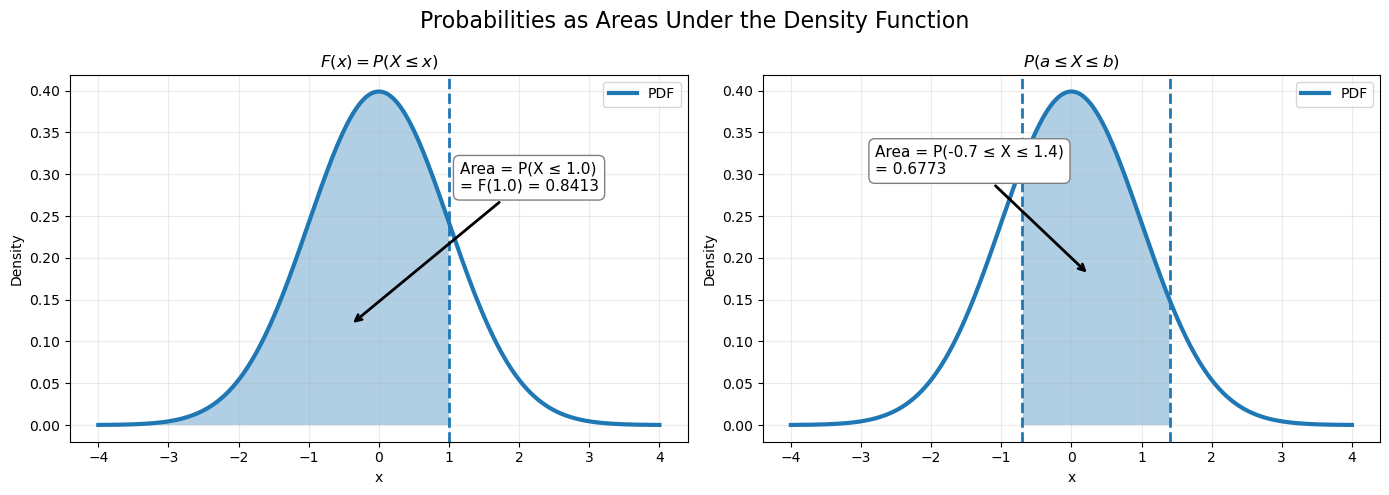

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Common x-grid
x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# =====================================================
# Left: CDF as accumulated area
# =====================================================

x0 = 1.0
prob1 = norm.cdf(x0)

ax = axes[0]

ax.plot(x, pdf, linewidth=3, label="PDF")

x_fill = x[x <= x0]
pdf_fill = norm.pdf(x_fill)

ax.fill_between(x_fill, pdf_fill, alpha=0.35)

ax.axvline(x0, linestyle="--", linewidth=2)

ax.annotate(
    f"Area = P(X ≤ {x0})\n= F({x0}) = {prob1:.4f}",
    xy=(-0.4, 0.12),
    xytext=(1.15, 0.28),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=2),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray")
)

ax.set_title(r"$F(x)=P(X\leq x)$")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend()

# =====================================================
# Right: Probability on an interval
# =====================================================

a = -0.7
b = 1.4

prob2 = norm.cdf(b) - norm.cdf(a)

ax = axes[1]

ax.plot(x, pdf, linewidth=3, label="PDF")

x_fill = x[(x >= a) & (x <= b)]
pdf_fill = norm.pdf(x_fill)

ax.fill_between(x_fill, pdf_fill, alpha=0.35)

ax.axvline(a, linestyle="--", linewidth=2)
ax.axvline(b, linestyle="--", linewidth=2)

ax.annotate(
    f"Area = P({a} ≤ X ≤ {b})\n= {prob2:.4f}",
    xy=(0.25, 0.18),
    xytext=(-2.8, 0.30),
    fontsize=11,
    arrowprops=dict(arrowstyle="->", lw=2),
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="gray")
)

ax.set_title(r"$P(a\leq X\leq b)$")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend()

plt.suptitle("Probabilities as Areas Under the Density Function", fontsize=16)

plt.tight_layout()
plt.show()

## Properties of the Probability Density Function

1. If the cumulative distribution function is differentiable, then

$$
p(x)=F'(x).
$$


2. Every probability density function integrates to one,

$$
\int_{-\infty}^{\infty}p(x)\,dx=1.
$$


3. The probability of any Borel set $B\subseteq\mathbb R$ is obtained by integrating the density over that set,

$$
P(B)=\int_B p(t)\,dt.
$$

In particular,

$$
P(a\le X\le b)=\int_a^b p(t)\,dt.
$$

## Examples of Absolutely Continuous Distributions

### Uniform Distribution

Let $ X\sim U([a,b])$, where $a<b$. The probability density function is

$$
p(x)=
\begin{cases}
\dfrac1{b-a},&a\le x\le b,\\[1ex]
0,&\text{otherwise}.
\end{cases}
$$

Every interval of the same length inside $[a,b]$ has the same probability.

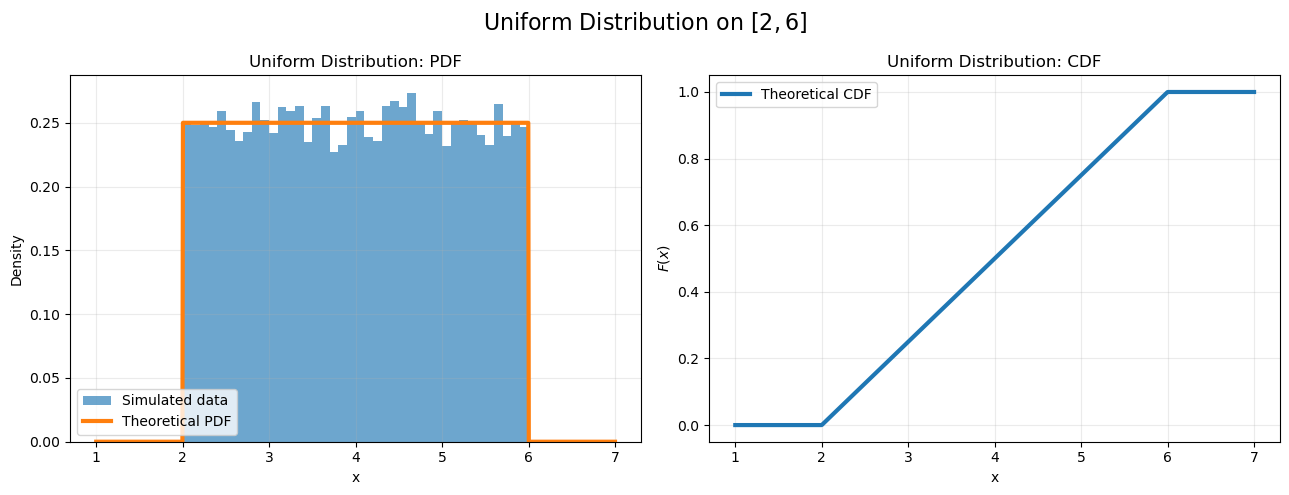

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform

# Parameters
a = 2
b = 6
n = 20_000

# Simulated sample
sample = np.random.uniform(a, b, size=n)

# Theoretical curves
x = np.linspace(a - 1, b + 1, 1000)
pdf = uniform.pdf(x, loc=a, scale=b - a)
cdf = uniform.cdf(x, loc=a, scale=b - a)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# =====================================================
# PDF
# =====================================================

ax = axes[0]

ax.hist(
    sample,
    bins=40,
    density=True,
    alpha=0.65,
    label="Simulated data"
)

ax.plot(
    x,
    pdf,
    linewidth=3,
    label="Theoretical PDF"
)

ax.set_title("Uniform Distribution: PDF")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend()

# =====================================================
# CDF
# =====================================================

ax = axes[1]

ax.plot(
    x,
    cdf,
    linewidth=3,
    label="Theoretical CDF"
)

ax.set_title("Uniform Distribution: CDF")
ax.set_xlabel("x")
ax.set_ylabel(r"$F(x)$")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend()

plt.suptitle(
    rf"Uniform Distribution on $[{a},{b}]$",
    fontsize=16
)

plt.tight_layout()
plt.show()


### Exponential Distribution

Let $X\sim\operatorname{Exp}(\lambda)$, where $\lambda>0$. Its probability density function is

$$
p(x)=
\begin{cases}
\lambda e^{-\lambda x},&x\ge0,\\[1ex]
0,&x<0.
\end{cases}
$$

The exponential distribution is commonly used to model **waiting times**.

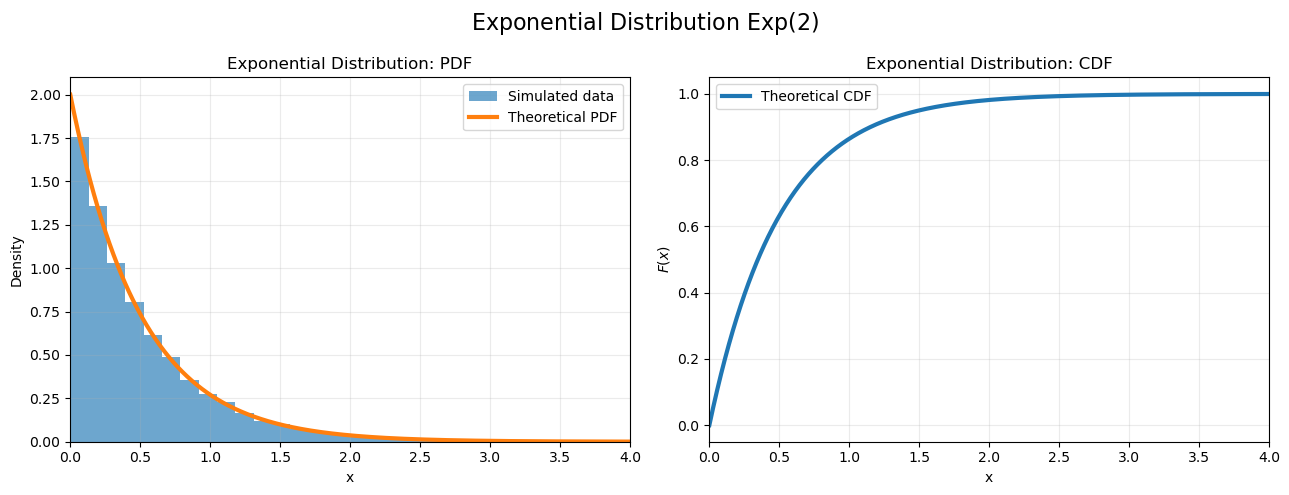

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon

# Parameters
lam = 2
n = 20_000

# Simulated sample
sample = np.random.exponential(scale=1/lam, size=n)

# Theoretical curves
x = np.linspace(0, 4, 1000)
pdf = expon.pdf(x, scale=1/lam)
cdf = expon.cdf(x, scale=1/lam)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# =====================================================
# PDF
# =====================================================

ax = axes[0]

ax.hist(
    sample,
    bins=40,
    density=True,
    alpha=0.65,
    label="Simulated data"
)

ax.plot(
    x,
    pdf,
    linewidth=3,
    label="Theoretical PDF"
)

ax.set_title(r"Exponential Distribution: PDF")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.set_xlim(0, 4)
ax.grid(alpha=0.25)
ax.legend()

# =====================================================
# CDF
# =====================================================

ax = axes[1]

ax.plot(
    x,
    cdf,
    linewidth=3,
    label="Theoretical CDF"
)

ax.set_title(r"Exponential Distribution: CDF")
ax.set_xlabel("x")
ax.set_ylabel(r"$F(x)$")
ax.set_xlim(0, 4)
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend()

plt.suptitle(
    r"Exponential Distribution $\mathrm{Exp}(2)$",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Normal Distribution

A random variable is said to follow a **normal distribution** with parameters $\mu\in\mathbb R$ and $\sigma^2>0$, if its probability density function is

$$
p(x)=
\frac1{\sqrt{2\pi}\sigma}
\exp\!\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right).
$$

We write

$$
\boxed{
X\sim N(\mu,\sigma^2)
}
$$

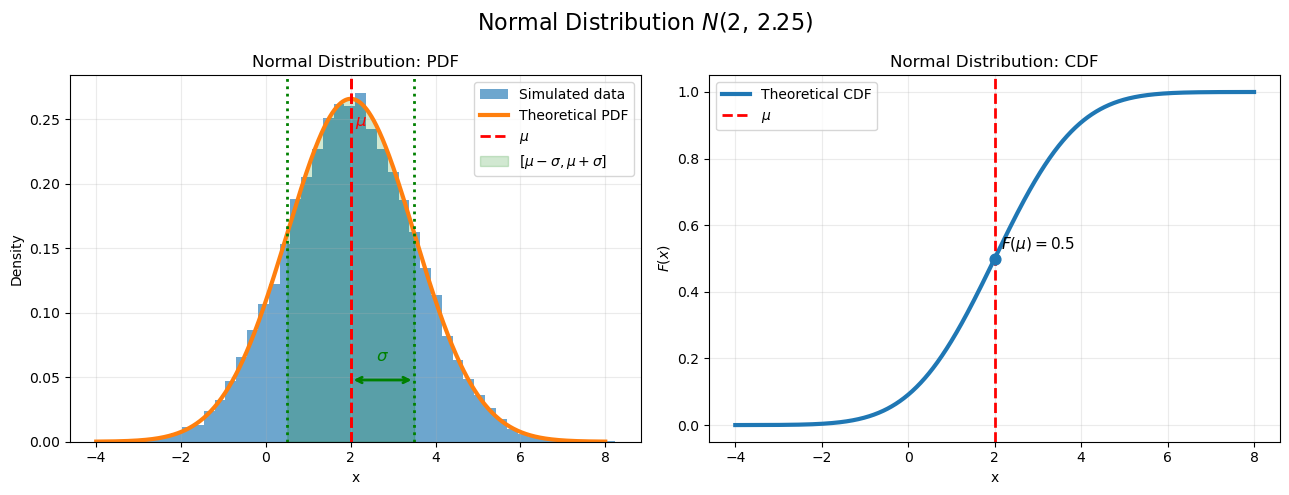

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Parameters
mu = 2
sigma = 1.5
n = 20_000

# Simulated sample
sample = np.random.normal(mu, sigma, size=n)

# Theoretical curves
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
pdf = norm.pdf(x, loc=mu, scale=sigma)
cdf = norm.cdf(x, loc=mu, scale=sigma)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# =====================================================
# PDF
# =====================================================

ax = axes[0]

ax.hist(
    sample,
    bins=45,
    density=True,
    alpha=0.65,
    label="Simulated data"
)

ax.plot(
    x,
    pdf,
    linewidth=3,
    label="Theoretical PDF"
)

ax.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$\mu$"
)

ax.text(
    mu + 0.1,
    np.max(pdf) * 0.92,
    r"$\mu$",
    color="red",
    fontsize=12
)

# Mean
ax.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=2,
    #label=r"$\mu$"
)

# One standard deviation
ax.axvline(
    mu - sigma,
    color="green",
    linestyle=":",
    linewidth=2
)

ax.axvline(
    mu + sigma,
    color="green",
    linestyle=":",
    linewidth=2
)

# Horizontal arrow showing sigma
y_arrow = np.max(pdf) * 0.18

ax.annotate(
    "",
    xy=(mu + sigma, y_arrow),
    xytext=(mu, y_arrow),
    arrowprops=dict(arrowstyle="<->", lw=2, color="green")
)

ax.text(
    mu + sigma/2,
    y_arrow + 0.015,
    r"$\sigma$",
    color="green",
    fontsize=12,
    ha="center"
)

# Shade the interval [mu-sigma, mu+sigma]
x_fill = x[(x >= mu - sigma) & (x <= mu + sigma)]

ax.fill_between(
    x_fill,
    norm.pdf(x_fill, mu, sigma),
    alpha=0.18,
    color="green",
    label=r"$[\mu-\sigma,\mu+\sigma]$"
)
ax.set_title("Normal Distribution: PDF")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend()

# =====================================================
# CDF
# =====================================================

ax = axes[1]

ax.plot(
    x,
    cdf,
    linewidth=3,
    label="Theoretical CDF"
)

ax.axvline(
    mu,
    color="red",
    linestyle="--",
    linewidth=2,
    label=r"$\mu$"
)

ax.scatter([mu], [0.5], s=60, zorder=5)

ax.text(
    mu + 0.15,
    0.53,
    r"$F(\mu)=0.5$",
    fontsize=11
)

ax.set_title("Normal Distribution: CDF")
ax.set_xlabel("x")
ax.set_ylabel(r"$F(x)$")
ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)
ax.legend()

plt.suptitle(
    rf"Normal Distribution $N({mu},\,{sigma**2:.2f})$",
    fontsize=16
)

plt.tight_layout()
plt.show()

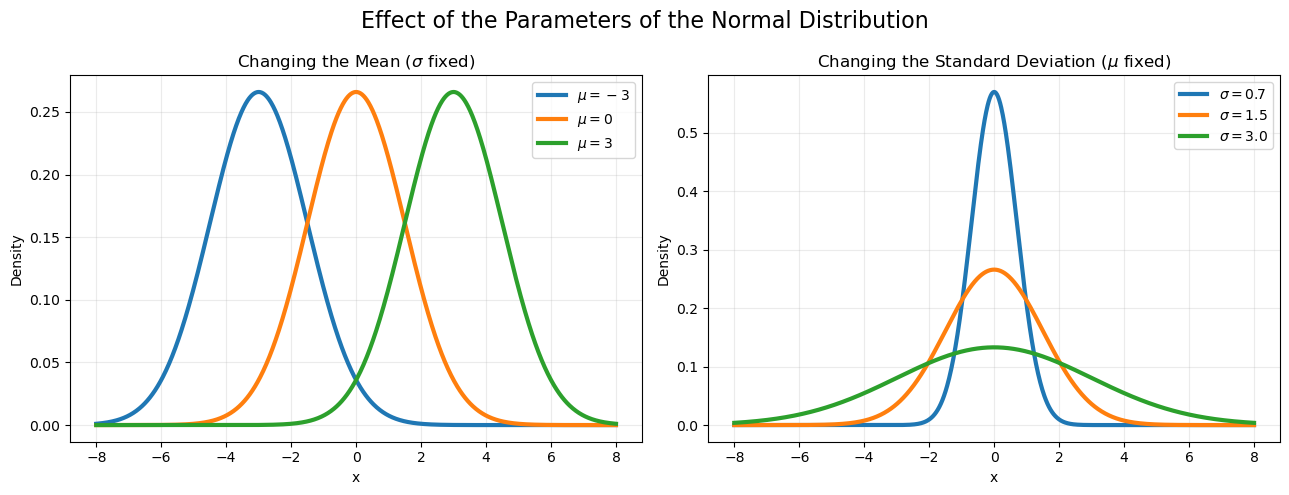

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# =====================================================
# Effect of changing the mean
# =====================================================

x = np.linspace(-8, 8, 1000)
sigma = 1.5
mus = [-3, 0, 3]

ax = axes[0]

for mu in mus:
    ax.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        linewidth=3,
        label=rf"$\mu={mu}$"
    )

ax.set_title(r"Changing the Mean ($\sigma$ fixed)")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend()

# =====================================================
# Effect of changing the standard deviation
# =====================================================

x = np.linspace(-8, 8, 1000)
mu = 0
sigmas = [0.7, 1.5, 3.0]

ax = axes[1]

for sigma in sigmas:
    ax.plot(
        x,
        norm.pdf(x, loc=mu, scale=sigma),
        linewidth=3,
        label=rf"$\sigma={sigma}$"
    )

ax.set_title(r"Changing the Standard Deviation ($\mu$ fixed)")
ax.set_xlabel("x")
ax.set_ylabel("Density")
ax.grid(alpha=0.25)
ax.legend()

plt.suptitle(
    "Effect of the Parameters of the Normal Distribution",
    fontsize=16
)

plt.tight_layout()
plt.show()

The normal distribution is one of the most important probability distributions in statistics and data science. Many natural phenomena are approximately normally distributed, and many statistical procedures are based on this distribution.

A particularly important special case is the **standard normal distribution**

$$
N(0,1),
$$

which will play a central role throughout the remainder of the course.

## The Standard Normal Table

The cumulative distribution function of the standard normal distribution, $Z\sim N(0,1)$, is denoted by

$$
\Phi(z)=P(Z\le z).
$$

Unlike the cumulative distribution functions of the uniform or exponential distributions, the integral

$$
\Phi(z)
=
\frac1{\sqrt{2\pi}}
\int_{-\infty}^{z}
e^{-t^2/2}\,dt
$$

cannot be evaluated using elementary functions.

For this reason, values of $\Phi(z)$ are usually obtained from a **standard normal table**, often called the **Z-table**.

### How is the Z-table organized?

The Z-table contains numerical values of $\Phi(z)=P(Z\le z)$ for many values of $z$.

Typically,

- the **row** contains the first decimal digit of $z$;
- the **column** contains the second decimal digit.

Suppose we want to compute $P(Z\le1.23)$. Looking up the entry corresponding to row **1.2**, and column **0.03**, we obtain approximately

$$
\boxed{\Phi(1.23)\approx0.8907.}
$$

Therefore,

$$
P(N(0,1)\le1.23)\approx0.8907.
$$

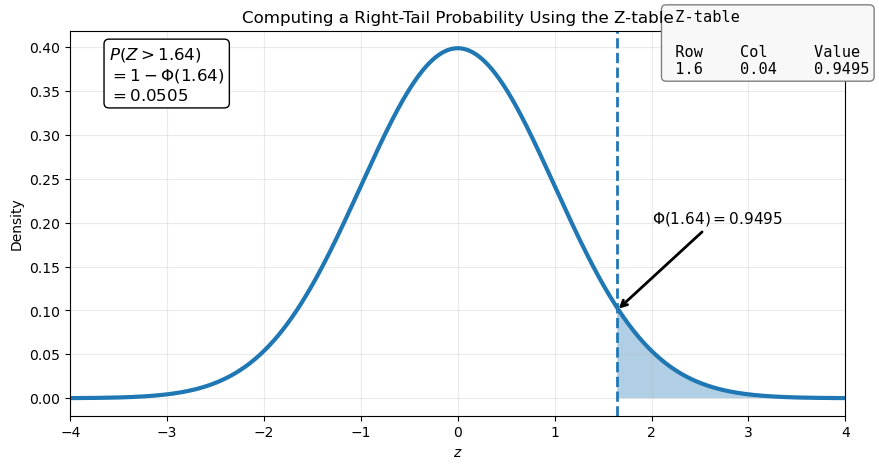

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Example
z = 1.64

x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x)

# Right tail
x_fill = x[x >= z]
pdf_fill = norm.pdf(x_fill)

left_prob = norm.cdf(z)
right_prob = 1 - left_prob

plt.figure(figsize=(10, 5))

# PDF
plt.plot(x, pdf, linewidth=3)
plt.fill_between(x_fill, pdf_fill, alpha=0.35)

plt.axvline(z, linestyle="--", linewidth=2)

# Probability annotation
plt.text(
    -3.6,
    0.34,
    rf"$P(Z>{z})$"
    "\n"
    rf"$=1-\Phi({z})$"
    "\n"
    rf"$={right_prob:.4f}$",
    fontsize=12,
    bbox=dict(boxstyle="round", fc="white")
)

# -------------------------------------------------
# Fake Z-table
# -------------------------------------------------

table_text = (
    " Z-table\n\n"
    " Row    Col     Value\n"
    " 1.6    0.04    0.9495"
)

plt.text(
    2.15,
    0.37,
    table_text,
    fontsize=11,
    family="monospace",
    bbox=dict(boxstyle="round", fc="#F8F8F8", ec="gray")
)

plt.annotate(
    r"$\Phi(1.64)=0.9495$",
    xy=(z, 0.10),
    xytext=(2.0, 0.20),
    arrowprops=dict(arrowstyle="->", lw=2),
    fontsize=11
)

plt.title(r"Computing a Right-Tail Probability Using the Z-table")
plt.xlabel("$z$")
plt.ylabel("Density")
plt.grid(alpha=0.25)

plt.xlim(-4,4)

plt.show()

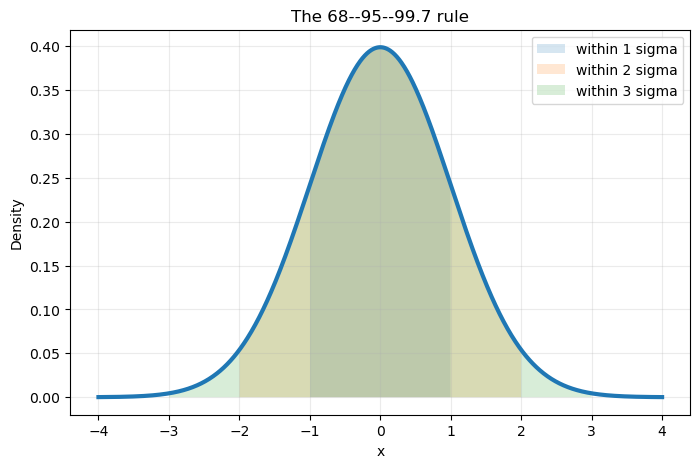

In [35]:
mu = 0
sigma = 1

x = np.linspace(-4, 4, 1000)
pdf = norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(8, 5))
plt.plot(x, pdf, linewidth=3)

for k in [1, 2, 3]:
    x_fill = x[(x >= mu - k * sigma) & (x <= mu + k * sigma)]
    plt.fill_between(x_fill, norm.pdf(x_fill), alpha=0.18, label=f"within {k} sigma")

plt.title("The 68--95--99.7 rule")
plt.xlabel("x")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.25)
plt.show()